# 04 Deep Baseline Notes

## 1. Week 4 goal
## 2. Deep baseline design
## 3. Kaggle training record
## 4. Validation results
## 5. Comparison with week 3 baselines

## Environment note

The deep baseline will be run mainly on Kaggle to avoid local environment limitations and to ensure reproducibility.

选取train20000,val10000条

In [1]:
import pandas as pd

results_compare = pd.DataFrame([
    {"model": "TFIDF_title_LR", "auc": 0.579711, "logloss": 0.607928},
    {"model": "TFIDF_title_abstract_LR", "auc": 0.596899, "logloss": 0.613277},
    {"model": "LightGBM_tabular", "auc": 0.625116, "logloss": 0.167376},
    {"model": "PyTorch_deep_baseline", "auc": 0.595534, "logloss": 0.171785},
])

results_compare

,model,auc,logloss
0,TFIDF_title_LR,0.579711,0.607928
1,TFIDF_title_abstract_LR,0.596899,0.613277
2,LightGBM_tabular,0.625116,0.167376
3,PyTorch_deep_baseline,0.595534,0.171785


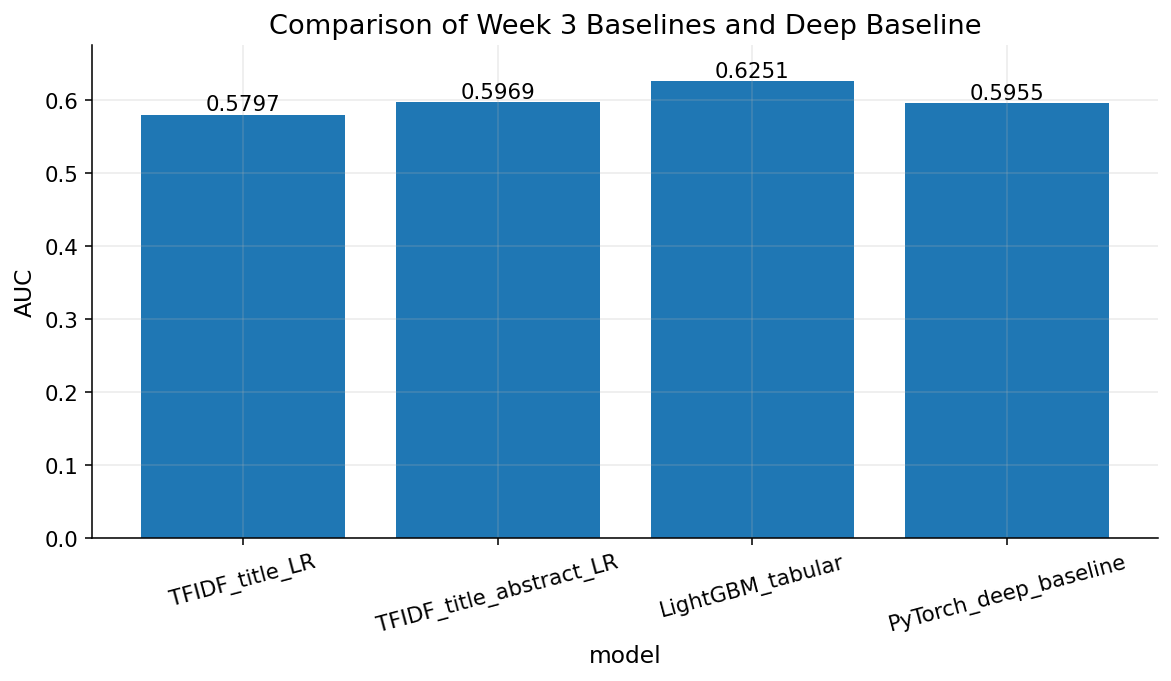

In [2]:
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path("..")

plt.rcParams["figure.dpi"] = 140
plt.rcParams["figure.figsize"] = (8.5, 5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

fig, ax = plt.subplots()
bars = ax.bar(results_compare["model"], results_compare["auc"])

ax.set_title("Comparison of Week 3 Baselines and Deep Baseline")
ax.set_xlabel("model")
ax.set_ylabel("AUC")
ax.set_ylim(0, max(results_compare["auc"]) * 1.08)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.4f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=15)
plt.tight_layout()

save_path = BASE_DIR / "results" / "figures" / "week4_ml_vs_deep_auc.png"
plt.savefig(save_path, bbox_inches="tight")
plt.show()

In [3]:
save_path = BASE_DIR / "results" / "tables" / "week4_deep_compare_results.csv"
results_compare.to_csv(save_path, index=False)
print("saved:", save_path)

saved: ../results/tables/week4_deep_compare_results.csv
